ref: ../mhn/test_calculate_metrics

benchmark method and 

In [1]:
import cfe

cfe.logger.setLevel("DEBUG")
# cfe.logger.setLevel("INFO")

backend = "cfe_docker"
# backend = "conda"
cfe.settings.backend = backend

[10/21/2025 05:07:27] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

read trajectory result

[10/21/2025 05:07:29] DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                  
                      DEBUG    recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                        
                      DEBUG    unserialize trajectory dict: '20251020_161304__scvelo-cfe_docker__JV5pLHC89R'                                                                                            
                      DEBUG    parse 'MilestoneWrapper' object for 20251020_161304__scvelo-cfe_docker__JV5pLHC89R                                                                                   

<Axes: title={'center': 'ref(milestone)'}, xlabel='X_umap1', ylabel='X_umap2'>

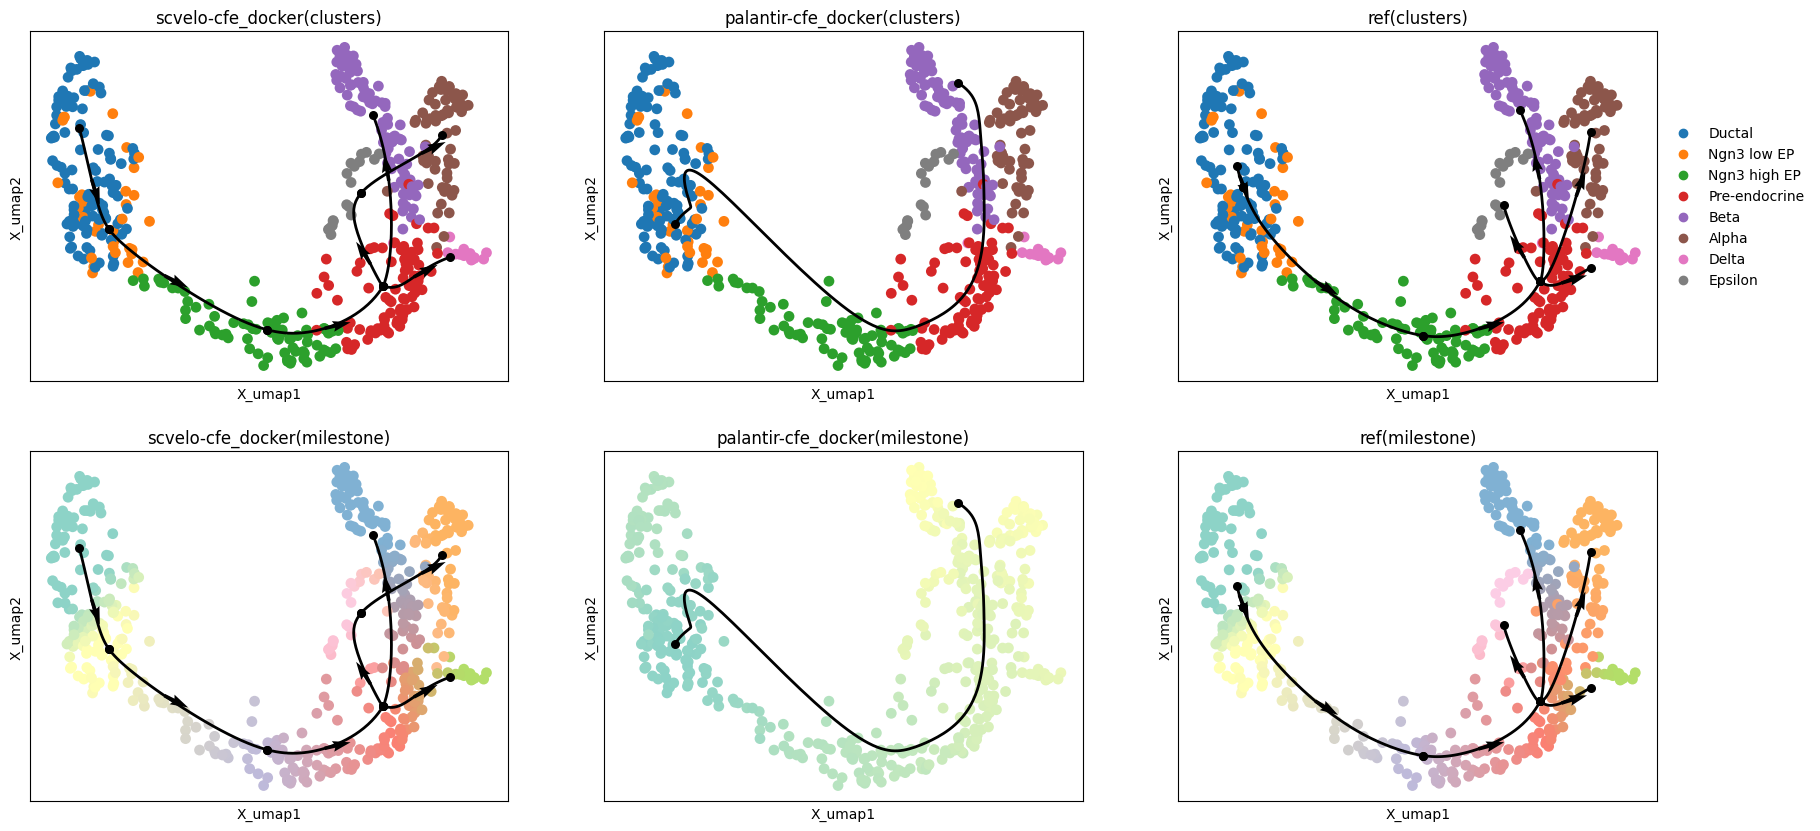

In [2]:
fadata = cfe.data.read_h5ad("output.h5ad")

model_name_list = fadata.get_all_model_name(parse=False)
color_list = ["clusters", "milestone"]

cfe.plot.plot_trajectory(fadata, model_name=model_name_list, color=color_list)

calculate metric

In [ ]:
metrics = [
    "time",
    "memory",
    "isomorphic",
    "edge_flip",
    "him",
    "correlation",
    "F1_branches",
    "F1_milestones",
]
metric_df = cfe.metric.calculate_metrics(fadata, metrics=metrics,)
metric_df

,time,memory,isomorphic,edge_flip,him,correlation,F1_branches,F1_milestones
20251020_161304__scvelo-cfe_docker__JV5pLHC89R,7.659824,312.69,0.0,0.857143,0.794244,NaN,0.867640,0.963859
20251020_161314__palantir-cfe_docker__HciMibnvCH,17.053221,3875.58,0.0,0.000000,0.272876,NaN,0.187328,0.284390


: 

: 

: 

: 

: 

: 

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import funkyheatmappy

plt.figure(figsize=(24, 18))

# fix benchmark dataframe
metric_df["id"] = [cfe.util.parse_random_time_string(i).split('-')[0] for i in metric_df.index]
metric_df["overall"] = np.arange(metric_df.shape[0]) # TODO: overall score need optimize
metric_df["time"] = metric_df["time"].round(2)
metric_df["memory"] = metric_df["memory"].round(2)

column_lists = [
    ["id", "group", "name", "geom", "options", "palette"],
    ["id", np.nan, "", "text", {"ha": 0, "width": 6}, np.nan],
    ["overall", "overall", "Overall", "bar", {"width": 4, "legend": False}, "palette1"],
    # metric group
    ["edge_flip", "group1", "Edge Flip", "funkyrect", "options", "palette1"],
    ["him", "group1", "HIM", "funkyrect", "options", "palette1"],
    # ["isomorphic", "group1", "Isomorphic", "funkyrect", "options", "palette1"],
    ["F1_branches", "group1", "F1 Branches", "funkyrect", "options", "palette1"],
    ["F1_milestones", "group1", "F1 Milestones", "funkyrect", "options", "palette1"],
    # resource group
    ["time", "group2", "Time", "rect", "scaling", "palette2"],
    ["time", "group2", "", "text", "scaling", "white6black4"], # add time value text
    ["memory", "group2", "Memory", "rect", "scaling", "palette2"],
    ["memory", "group2", "", "text", "scaling", "white6black4"], # add value text

]

column_info = pd.DataFrame(column_lists[1:], columns=column_lists[0])
column_info.index = column_info["id"]

column_groups = pd.DataFrame(
    columns=["Category", "group", "palette"],
    data=[["Overall", "overall", "palette1"],
          ["Metric", "group1", "palette1"],
          ["Resources", "group2", "palette2"]]
)

funkyheatmappy.funky_heatmap(metric_df, column_info=column_info, column_groups=column_groups)

plt.savefig("benchmark_heatmap.pdf", dpi=300)
plt.show()

ModuleNotFoundError: No module named 'funkyheatmappy'

: 

: 

: 

: 

: 

: 

: 